In [4]:
import pandas as pd

In [7]:
import os
os.listdir()

['.config', 'sample_data']

In [9]:
import os
os.listdir()

['.config', 'Airplane_Crashes_and_Fatalities_Since_1908.csv', 'sample_data']

In [10]:
import pandas as pd

df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [12]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 5268
Number of columns: 13


In [13]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [14]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


In [15]:
text_columns = [
    'Time',
    'Location',
    'Operator',
    'Flight #',
    'Route',
    'Type',
    'Registration',
    'cn/In'
]

for column in text_columns:
    df[column] = df[column].fillna('Unknown')

df['Summary'] = df['Summary'].fillna('No summary available')

In [16]:
numeric_columns = ['Aboard', 'Fatalities', 'Ground']

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [17]:
df.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,0
Route,0
Type,0
Registration,0
cn/In,0
Aboard,0


In [18]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [19]:
fatality_locations.loc[
    fatality_locations['Fatalities'].idxmax(),
    ['Date', 'Fatalities']
]

,2963
Date,03/27/1977
Fatalities,583.0


In [20]:
fatality_locations[['Aboard', 'Fatalities']].head(20)

,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0
5,41.0,21.0
6,19.0,19.0
7,20.0,20.0
8,22.0,22.0
9,19.0,19.0


In [21]:
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location'].str.split(',', n=1, expand=True)
)

fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State/Country'] = fatality_locations['State/Country'].str.strip()

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [22]:
df.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,0
Route,0
Type,0
Registration,0
cn/In,0
Aboard,0


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.dtypes

,0
Date,object
Time,object
Location,object
Operator,object
Flight #,object
Route,object
Type,object
Registration,object
cn/In,object
Aboard,float64


In [25]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [26]:
df['Date'].dtype

dtype('<M8[ns]')

In [27]:
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,Unknown,Demonstration,Wright Flyer III,Unknown,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1912-07-12,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,Unknown,Test flight,Dirigible,Unknown,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,1913-08-06,Unknown,"Victoria, British Columbia, Canada",Private,-,Unknown,Curtiss seaplane,Unknown,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,1913-09-09,18:30,Over the North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (airship),Unknown,Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,1913-10-17,10:30,"Near Johannisthal, Germany",Military - German Navy,Unknown,Unknown,Zeppelin L-2 (airship),Unknown,Unknown,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [28]:
df.to_csv('cleaned_aircraft_accidents.csv', index=False)

In [29]:
import os
os.path.exists('cleaned_aircraft_accidents.csv')

True

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          5268 non-null   datetime64[ns]
 1   Time          5268 non-null   object        
 2   Location      5268 non-null   object        
 3   Operator      5268 non-null   object        
 4   Flight #      5268 non-null   object        
 5   Route         5268 non-null   object        
 6   Type          5268 non-null   object        
 7   Registration  5268 non-null   object        
 8   cn/In         5268 non-null   object        
 9   Aboard        5268 non-null   float64       
 10  Fatalities    5268 non-null   float64       
 11  Ground        5268 non-null   float64       
 12  Summary       5268 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(9)
memory usage: 535.2+ KB


In [31]:
df.shape

(5268, 13)

In [32]:
df.describe()

,Date,Aboard,Fatalities,Ground
count,5268,5268.000000,5268.000000,5268.000000
mean,1971-10-23 15:50:42.369020480,27.493736,20.043090,1.602126
min,1908-09-17 00:00:00,0.000000,0.000000,0.000000
25%,1954-04-11 18:00:00,5.000000,3.000000,0.000000
50%,1973-03-04 00:00:00,13.000000,9.000000,0.000000
75%,1990-06-26 18:00:00,30.000000,23.000000,0.000000
max,2009-06-08 00:00:00,644.000000,583.000000,2750.000000
std,NaN,42.996900,33.166309,53.875057


In [33]:
df.to_csv('cleaned_aircraft_accidents.csv', index=False)

In [34]:
import os
os.path.exists('cleaned_aircraft_accidents.csv')

True

In [35]:
cleaned_df = pd.read_csv('cleaned_aircraft_accidents.csv')

In [36]:
cleaned_df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,Unknown,Demonstration,Wright Flyer III,Unknown,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1912-07-12,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,Unknown,Test flight,Dirigible,Unknown,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,1913-08-06,Unknown,"Victoria, British Columbia, Canada",Private,-,Unknown,Curtiss seaplane,Unknown,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,1913-09-09,18:30,Over the North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (airship),Unknown,Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,1913-10-17,10:30,"Near Johannisthal, Germany",Military - German Navy,Unknown,Unknown,Zeppelin L-2 (airship),Unknown,Unknown,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [37]:
cleaned_df.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,0
Route,0
Type,0
Registration,0
cn/In,0
Aboard,0


In [38]:
cleaned_df.duplicated().sum()

np.int64(0)

In [39]:
cleaned_df.shape

(5268, 13)

In [40]:
df.shape

(5268, 13)

In [41]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,2008-03-15,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,Unknown,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,2008-04-03,11:00,"Lawa, Suriname",Blue Wing Airlines,Unknown,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,2008-04-09,23:27,"Bundeena, Australia",Avtex Air Services,Unknown,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,2008-04-11,22:15,"Chrisinau, Moldova",Kata Transportation,Unknown,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,2008-04-15,14:30,"Goma, Congo",Hewa Bora Airways,Unknown,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,2009-05-20,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,Unknown,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,2009-05-26,Unknown,"Near Isiro, DemocratiRepubliCongo",Service Air,Unknown,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,0.0,The cargo plane crashed while on approach to I...
5265,2009-06-01,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,2009-06-07,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,Unknown,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [42]:
df.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,0
Route,0
Type,0
Registration,0
cn/In,0
Aboard,0


In [1]:
df_raw = pd.read_csv("/content/your_dataset_name.csv")

df_raw.isnull().sum()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

In [3]:
df.isnull().sum()

NameError: name 'df' is not defined

In [4]:
import pandas as pd

In [5]:
df_raw = pd.read_csv("/mnt/data/842a2756-864b-459c-ac98-fe52588aaaa8.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/842a2756-864b-459c-ac98-fe52588aaaa8.csv'

In [6]:
from google.colab import files

uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


In [7]:
import pandas as pd

df_raw = pd.read_csv(next(iter(uploaded)))

In [8]:
df_raw.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


In [9]:
df_raw.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


In [10]:
fatality_locations = df_raw[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

fatality_locations

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
...,...,...,...,...
5263,05/20/2009,"Near Madiun, Indonesia",112.0,98.0
5264,05/26/2009,"Near Isiro, DemocratiRepubliCongo",4.0,4.0
5265,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",228.0,228.0
5266,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",1.0,1.0


In [11]:
fatality_locations.loc[
    fatality_locations['Fatalities'].idxmax(),
    ['Date', 'Fatalities']
]

,2963
Date,03/27/1977
Fatalities,583.0


In [12]:
fatality_locations[['Aboard', 'Fatalities']]

,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0
...,...,...
5263,112.0,98.0
5264,4.0,4.0
5265,228.0,228.0
5266,1.0,1.0


In [13]:
(fatality_locations['Fatalities'] == 0).sum()

np.int64(58)

In [14]:
fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [15]:
top_100_fatalities = fatality_locations.sort_values(
    by='Fatalities',
    ascending=False
).head(100)

top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


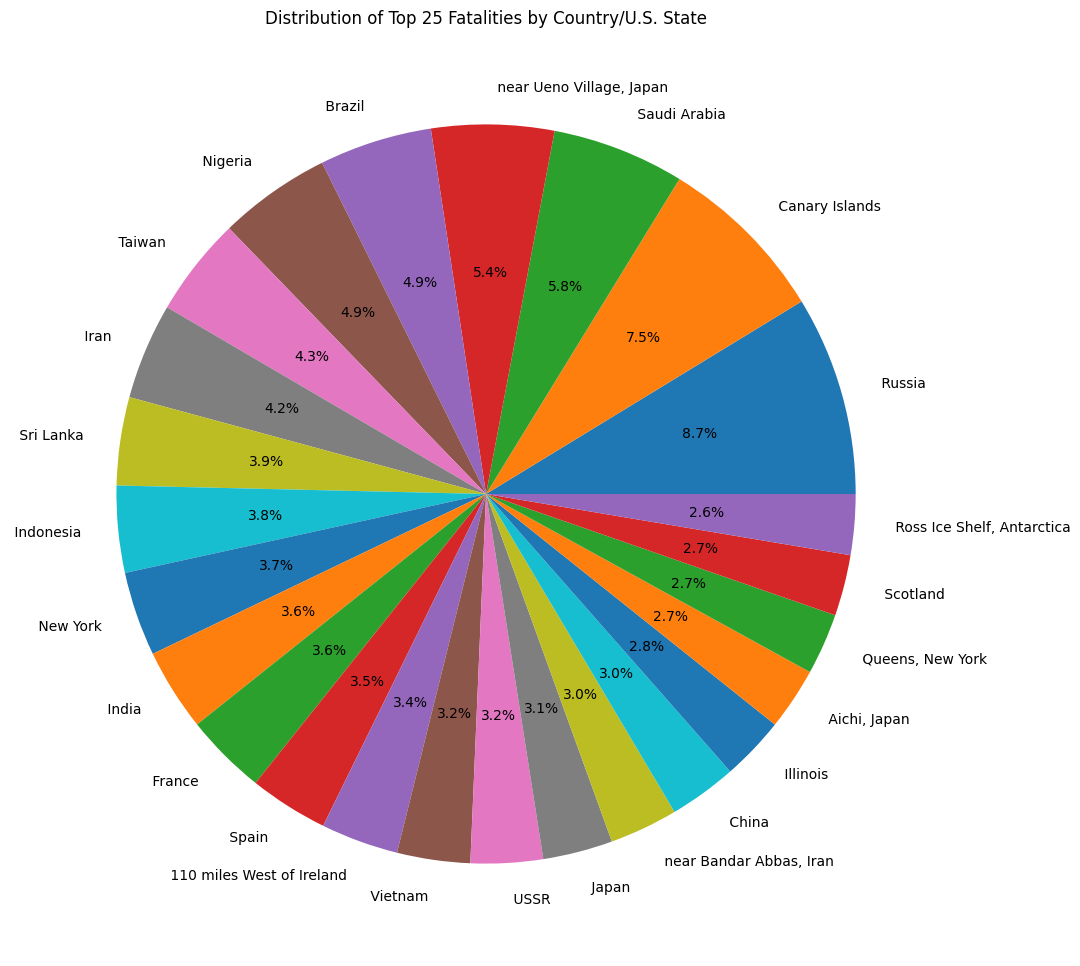

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

top_25_locations = (
    top_100_fatalities.groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(12, 12))

plt.pie(
    top_25_locations,
    labels=top_25_locations.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Top 25 Fatalities by Country/U.S. State')
plt.show()